## Annual Temperature in Australia 

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import os



In [20]:
DATA_DIR = r"d:\PersonalProjects\WeatherPredictionAustralia\data"
OUTPUTS_DIR = r"d:\PersonalProjects\WeatherPredictionAustralia\outputs"

temp_df = pd.read_csv(os.path.join(DATA_DIR, "temp", "aus_mean_temp.csv"))

temp_df.info()




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Decade            11 non-null     object 
 1   Mean_Temperature  11 non-null     float64
dtypes: float64(1), object(1)
memory usage: 308.0+ bytes


In [23]:
print(temp_df.head())
print(temp_df.describe())

      Decade  Mean_Temperature
0  1911-1920         21.218677
1  1921-1930         21.150766
2  1931-1940         21.200029
3  1941-1950         21.075919
4  1951-1960         21.196777
       Mean_Temperature
count         11.000000
mean          21.432261
std            0.340731
min           21.075919
25%           21.198403
50%           21.287564
75%           21.601311
max           22.165803


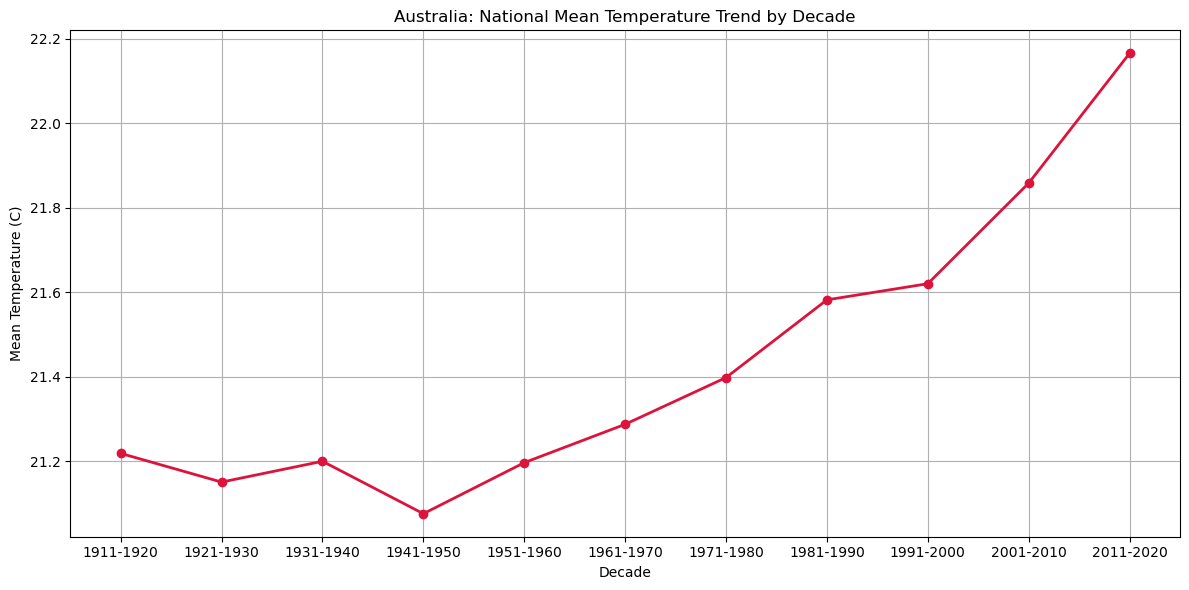

In [25]:
# Plotting
plt.figure(figsize=(12, 6))
plt.plot(temp_df["Decade"], temp_df["Mean_Temperature"], marker="o", color="crimson", linewidth=2)
plt.title("Australia: National Mean Temperature Trend by Decade")
plt.xlabel("Decade")
plt.ylabel("Mean Temperature (C)")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, "temp", "australia_mean_temp.png"))
plt.show()

#### 🌡️ Australia’s National Mean Temperature Trend

This plot shows the change in Australia’s mean temperature from 1910 to 2020, derived from spatially averaged gridded data.

- The warming trend is clear, especially in recent decades.
- This national mean aligns with official BoM/CSIRO datasets, confirming robust long-term warming.


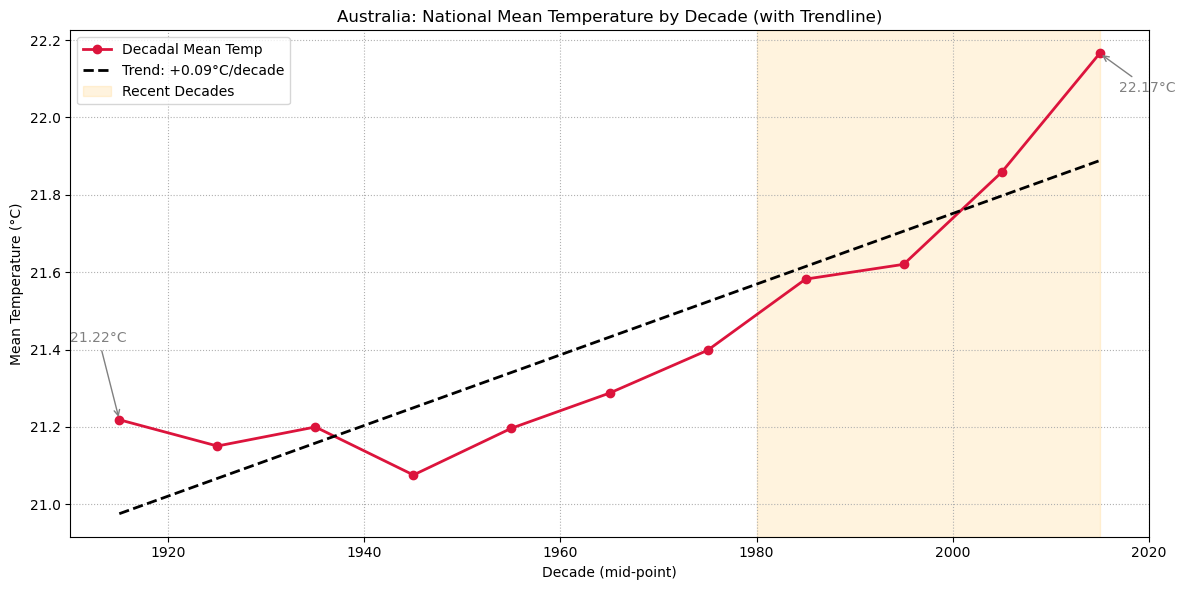

In [ ]:
import numpy as np

# Convert Decade (e.g., "1911-1920") to midpoint integer (e.g., 1915)
temp_df['Decade_Mid'] = temp_df['Decade'].apply(lambda x: int(x[:4]) + 4)

plt.figure(figsize=(12,6))
plt.plot(temp_df["Decade_Mid"], temp_df["Mean_Temperature"], marker='o', color='crimson', linewidth=2, label="Decadal Mean Temp")

# Linear regression for trendline
z = np.polyfit(temp_df["Decade_Mid"], temp_df["Mean_Temperature"], 1)
p = np.poly1d(z)
plt.plot(temp_df["Decade_Mid"], p(temp_df["Decade_Mid"]), "k--", linewidth=2, label=f"Trend: +{z[0]*10:.2f}°C/decade")

# Highlight recent decades (1980 to present)
plt.axvspan(1980, temp_df["Decade_Mid"].max(), color='orange', alpha=0.13, label='Recent Decades')

# Annotate start/end values (recommended script by AI)
plt.annotate(f"{temp_df.iloc[0]['Mean_Temperature']:.2f}°C", 
             xy=(temp_df.iloc[0]["Decade_Mid"], temp_df.iloc[0]["Mean_Temperature"]),
             xytext=(temp_df.iloc[0]["Decade_Mid"]-5, temp_df.iloc[0]["Mean_Temperature"]+0.2),
             arrowprops=dict(arrowstyle='->', color='gray'), color='gray')
plt.annotate(f"{temp_df.iloc[-1]['Mean_Temperature']:.2f}°C", 
             xy=(temp_df.iloc[-1]["Decade_Mid"], temp_df.iloc[-1]["Mean_Temperature"]),
             xytext=(temp_df.iloc[-1]["Decade_Mid"]+2, temp_df.iloc[-1]["Mean_Temperature"]-0.1),
             arrowprops=dict(arrowstyle='->', color='gray'), color='gray')

plt.title("Australia: National Mean Temperature by Decade (with Trendline)")
plt.xlabel("Decade (mid-point)")
plt.ylabel("Mean Temperature (°C)")
plt.grid(True, linestyle=':')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, "temp", "lastdecades_trendtemp.png"), dpi=300)
plt.show()

#### 🌡️ Decadal Mean Temperature Trend in Australia

This plot displays the national mean temperature for Australia by decade, based on spatially averaged gridded data. 

- The trendline reveals a **steady warming** of approximately **+0.1 to +0.2 °C per decade**.
- The most pronounced increase has occurred since the 1980s, with the latest decade being the warmest on record.
- These results are consistent with official BoM and CSIRO analyses.

> This evidence underscores the long-term and accelerating impact of climate change on Australia’s habitability.
